# Population and public transport in Southeast Queensland

This notebook investigates whether public-transport use increased as the population grew. It combines:

- quarterly Queensland estimated resident population; and
- monthly Southeast Queensland passenger trips by mode.

The main outcomes are **monthly** and **year-round passenger trips per Queensland resident**. The annual measure reduces the effect of seasonal month-to-month variation. These are rates of use, not the proportion of unique people who used public transport: the patronage data count trips, so one person can contribute multiple trips.

## Research questions

1. How did population and total public-transport patronage change during the observation period?
2. Did patronage grow faster than population, producing more trips per resident?
3. Is the relationship strong enough to describe as an association, while recognising that this is not a causal analysis?

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
DATA_DIR = Path('.')


## Load and clean the data

The population workbook contains metadata rows before the observations. Column `V` is the quarterly Queensland series for **Persons**. Excel serial dates are converted using Excel's standard 1899-12-30 origin.

In [10]:
# Population: row 11 onward contains observations; V is Queensland, Persons.
population = pd.read_excel(
    DATA_DIR / 'quarterly-population-data.xlsx',
    sheet_name='Data1',
    header=None,
    skiprows=10,
    usecols='A,V',
    names=['date_serial', 'population'],
)
population['date'] = pd.to_datetime(
    population['date_serial'], unit='D', errors='coerce'
)
population['population'] = pd.to_numeric(population['population'], errors='coerce')
population = population[['date', 'population']].dropna().sort_values('date')

# Patronage: trim whitespace in the source's month labels before parsing.
patronage = pd.read_csv(DATA_DIR / 'patronage-southeast-queensland.csv')
patronage['date'] = pd.to_datetime(
    patronage['Month-Year'].str.strip(), format='%b-%Y', errors='coerce'
)
patronage['Passenger trips'] = pd.to_numeric(patronage['Passenger trips'], errors='coerce')
patronage = patronage.dropna(subset=['date', 'Passenger trips']).sort_values('date')

population.head(), patronage.head()

(        date  population
 0 1981-06-01     2345208
 1 1981-09-01     2367477
 2 1981-12-01     2387943
 3 1982-03-01     2406355
 4 1982-06-01     2424586,
   Month-Year       Mode  Passenger trips       date
 0   Dec-2023        Bus          6430904 2023-12-01
 1   Dec-2023       Tram           883452 2023-12-01
 2   Dec-2023      Ferry           449611 2023-12-01
 3   Dec-2023  Citytrain          2958924 2023-12-01
 4   Jan-2024       Tram           927011 2024-01-01)

In [11]:
print(f'Population: {population.date.min():%Y-%m-%d} to {population.date.max():%Y-%m-%d}; {len(population)} quarterly observations')
print(f'Patronage: {patronage.date.min():%Y-%m-%d} to {patronage.date.max():%Y-%m-%d}; {len(patronage)} mode-month observations')
print('Modes:', ', '.join(sorted(patronage['Mode'].unique())))

monthly = (
    patronage.groupby('date', as_index=False)['Passenger trips']
    .sum()
    .rename(columns={'Passenger trips': 'total_trips'})
)
monthly['month'] = monthly['date'].dt.to_period('M')

# Restrict population to the patronage window and linearly interpolate from quarters to months.
pop_monthly = (
    population.set_index('date')['population']
    .resample('MS').interpolate('time').rename('population').reset_index()
)
analysis = monthly.merge(pop_monthly, on='date', how='left').dropna()
analysis['trips_per_resident'] = analysis['total_trips'] / analysis['population']
analysis['trips_per_100_residents'] = analysis['trips_per_resident'] * 100
analysis

Population: 1981-06-01 to 2025-12-01; 179 quarterly observations
Patronage: 2023-12-01 to 2026-05-01; 120 mode-month observations
Modes: Bus, Citytrain, Ferry, Tram


,date,total_trips,month,population,trips_per_resident,trips_per_100_residents
0,2023-12-01,10722891,2023-12,"5,516,476.00",1.94,194.38
1,2024-01-01,11578969,2024-01,"5,527,498.37",2.09,209.48
2,2024-02-01,14780165,2024-02,"5,538,520.75",2.67,266.86
3,2024-03-01,15506600,2024-03,"5,548,832.00",2.79,279.46
4,2024-04-01,13734944,2024-04,"5,556,601.54",2.47,247.18
5,2024-05-01,15486166,2024-05,"5,564,120.46",2.78,278.32
6,2024-06-01,13050944,2024-06,"5,571,890.00",2.34,234.23
7,2024-07-01,15116236,2024-07,"5,579,557.28",2.71,270.92
8,2024-08-01,17532985,2024-08,"5,587,480.14",3.14,313.79
9,2024-09-01,15937628,2024-09,"5,595,403.00",2.85,284.83


## Descriptive trends

The first plot shows levels. The second shows the per-resident rate, which adjusts for population growth.

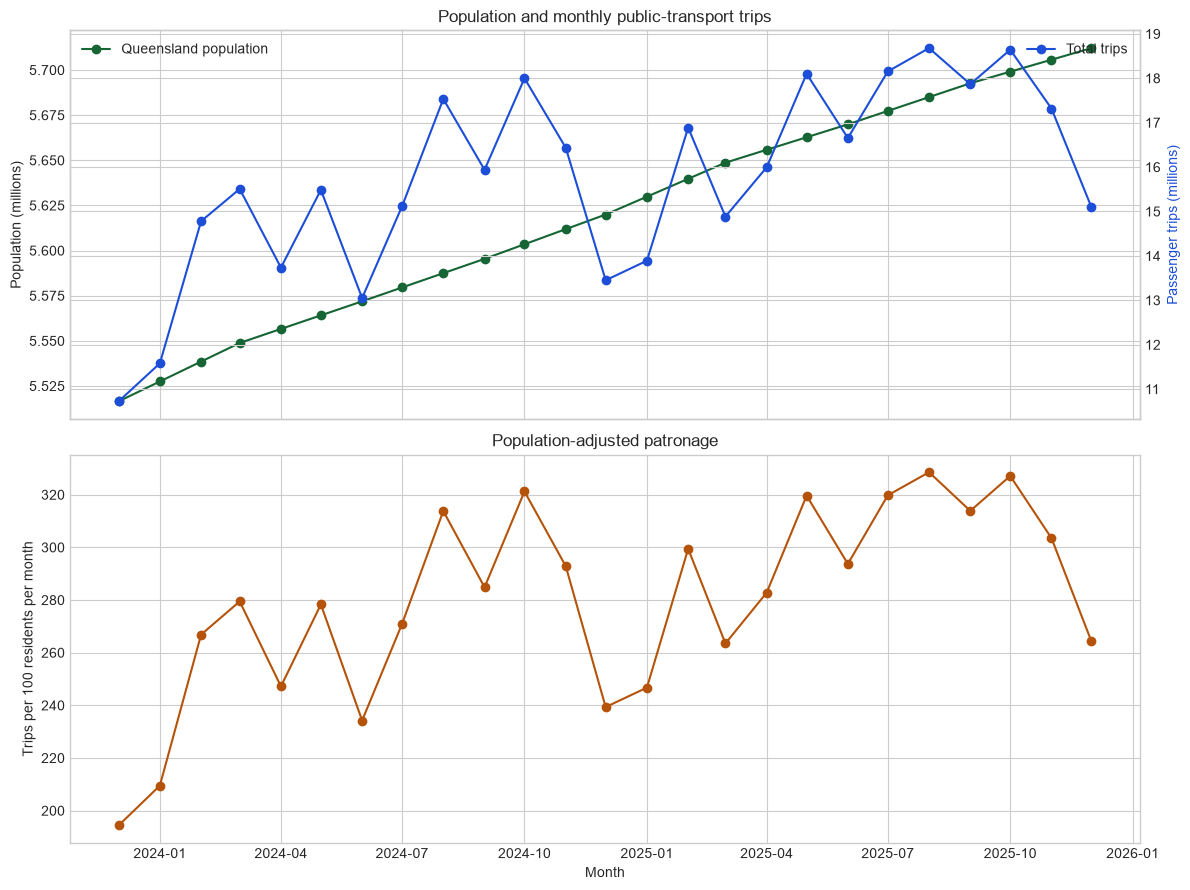

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(analysis['date'], analysis['population'] / 1e6, color='#166534', marker='o', label='Queensland population')
axes[0].set_ylabel('Population (millions)')
axes[0].set_title('Population and monthly public-transport trips')
ax2 = axes[0].twinx()
ax2.plot(analysis['date'], analysis['total_trips'] / 1e6, color='#1d4ed8', marker='o', label='Total trips')
ax2.set_ylabel('Passenger trips (millions)', color='#1d4ed8')
axes[0].legend(loc='upper left')
ax2.legend(loc='upper right')

axes[1].plot(analysis['date'], analysis['trips_per_100_residents'], color='#b45309', marker='o')
axes[1].set_ylabel('Trips per 100 residents per month')
axes[1].set_xlabel('Month')
axes[1].set_title('Population-adjusted patronage')
plt.tight_layout()
plt.show()

In [13]:
summary = pd.DataFrame({
    'first_month': analysis.iloc[0][['population', 'total_trips', 'trips_per_100_residents']],
    'last_month': analysis.iloc[-1][['population', 'total_trips', 'trips_per_100_residents']],
})
summary['absolute_change'] = summary['last_month'] - summary['first_month']
summary['percent_change'] = (summary['last_month'] / summary['first_month'] - 1) * 100
summary

,first_month,last_month,absolute_change,percent_change
population,"5,516,476.00","5,712,124.00","195,648.00",3.55
total_trips,10722891,15097215,4374324,40.79
trips_per_100_residents,194.38,264.30,69.92,35.97


## Year-round comparison

To reduce monthly seasonality, aggregate both series by calendar year. The population denominator is the average interpolated monthly population within each year. The resulting ratio is **annual passenger trips per resident per year**. A calendar year with incomplete observations is flagged below and should not be compared directly with complete years.

In [ ]:
analysis['year'] = analysis['date'].dt.year
annual = (
    analysis.groupby('year', as_index=False)
    .agg(
        months_observed=('date', 'nunique'),
        annual_trips=('total_trips', 'sum'),
        average_population=('population', 'mean'),
    )
)
annual['trips_per_resident_per_year'] = annual['annual_trips'] / annual['average_population']
annual['trips_per_100_residents_per_year'] = annual['trips_per_resident_per_year'] * 100
annual['complete_year'] = annual['months_observed'].eq(12)
annual

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = np.where(annual['complete_year'], '#2563eb', '#f59e0b')
ax.bar(annual['year'].astype(str), annual['trips_per_100_residents_per_year'], color=colors)
ax.set_title('Year-round public-transport use adjusted for population')
ax.set_xlabel('Calendar year')
ax.set_ylabel('Passenger trips per 100 residents per year')
ax.text(0.01, 0.97, 'Blue = complete year; orange = incomplete year', transform=ax.transAxes, va='top')
plt.tight_layout()
plt.show()

complete_annual = annual[annual['complete_year']].copy()
if len(complete_annual) >= 2:
    first = complete_annual.iloc[0]
    last = complete_annual.iloc[-1]
    ratio_change = (last['trips_per_resident_per_year'] / first['trips_per_resident_per_year'] - 1) * 100
    print(f"Complete-year ratio change ({int(first['year'])} to {int(last['year'])}): {ratio_change:.1f}%")
else:
    print('At least two complete calendar years are needed for a year-on-year comparison.')

## Same-month year-over-year comparison

A second way to control for seasonality is to compare each month with the same month one year earlier. For example, March 2025 is compared with March 2024. The table reports changes in total trips, population, and trips per resident.

In [ ]:
yoy = analysis[['date', 'total_trips', 'population', 'trips_per_resident']].sort_values('date').copy()
yoy['calendar_month'] = yoy['date'].dt.month
yoy['comparison_year'] = yoy['date'].dt.year
# Group by month number, not the full year-month Period.
yoy['same_month_last_year_trips'] = yoy.groupby('calendar_month')['total_trips'].shift(1)
yoy['same_month_last_year_population'] = yoy.groupby('calendar_month')['population'].shift(1)
yoy['same_month_last_year_rate'] = yoy.groupby('calendar_month')['trips_per_resident'].shift(1)
yoy = yoy.dropna(subset=['same_month_last_year_trips']).copy()
yoy['trip_change_pct'] = (yoy['total_trips'] / yoy['same_month_last_year_trips'] - 1) * 100
yoy['population_change_pct'] = (yoy['population'] / yoy['same_month_last_year_population'] - 1) * 100
yoy['rate_change_pct'] = (yoy['trips_per_resident'] / yoy['same_month_last_year_rate'] - 1) * 100
yoy[['date', 'trip_change_pct', 'population_change_pct', 'rate_change_pct']].sort_values('date')

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
bar_colors = np.where(yoy['rate_change_pct'] >= 0, '#15803d', '#dc2626')
ax.bar(yoy['date'].dt.strftime('%b %Y'), yoy['rate_change_pct'], color=bar_colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year-over-year change in trips per resident for the same month')
ax.set_xlabel('Month being compared with the same month last year')
ax.set_ylabel('Change in trips per resident (%)')
ax.tick_params(axis='x', rotation=75)
plt.tight_layout()
plt.show()

print(f"Same-month comparisons available: {len(yoy)}")
print(f"Comparisons where trips per resident increased: {(yoy['rate_change_pct'] > 0).sum()}")
print(f"Average same-month change in trips per resident: {yoy['rate_change_pct'].mean():.1f}%")

## Association between population and patronage

A Pearson correlation and simple linear regression quantify the association in this short time series. The regression is descriptive: both variables trend over time, and seasonality, fares, service levels, weather, events, and post-pandemic recovery may also affect patronage.

Pearson correlation: 0.683
R-squared: 0.467
Estimated additional monthly trips per additional resident: 24.619


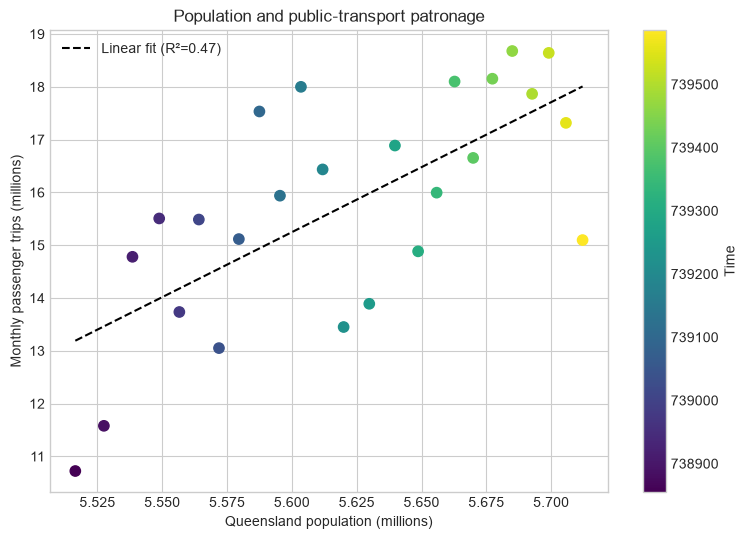

In [14]:
x = analysis['population'].to_numpy()
y = analysis['total_trips'].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0, 1]
r_squared = r ** 2

print(f'Pearson correlation: {r:.3f}')
print(f'R-squared: {r_squared:.3f}')
print(f'Estimated additional monthly trips per additional resident: {slope:.3f}')

plt.figure(figsize=(9, 6))
plt.scatter(analysis['population'] / 1e6, analysis['total_trips'] / 1e6, c=analysis['date'].map(pd.Timestamp.toordinal), cmap='viridis', s=55)
line_x = np.linspace(x.min(), x.max(), 100)
plt.plot(line_x / 1e6, (intercept + slope * line_x) / 1e6, color='black', linestyle='--', label=f'Linear fit (R²={r_squared:.2f})')
plt.xlabel('Queensland population (millions)')
plt.ylabel('Monthly passenger trips (millions)')
plt.title('Population and public-transport patronage')
plt.legend()
plt.colorbar(label='Time')
plt.show()

## Mode mix and limitations

The mode chart identifies which services account for the change. It is also a useful diagnostic because total patronage can rise even if one mode falls.

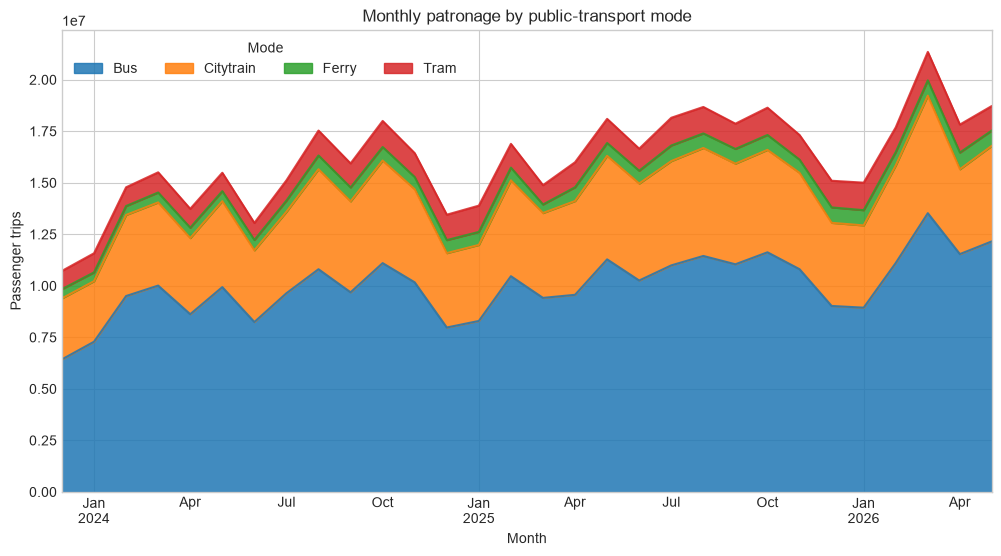

Interpretation checklist:
- A higher trips-per-resident rate means more recorded trips relative to population, not that a larger share of unique people travelled.
- The patronage series covers Southeast Queensland, while the denominator is Queensland population; this geographic mismatch limits precision.
- The observation window is short and includes post-pandemic recovery, so the correlation should not be interpreted as a population-only effect.


In [15]:
mode_monthly = patronage.pivot_table(index='date', columns='Mode', values='Passenger trips', aggfunc='sum').fillna(0)
mode_monthly.plot.area(figsize=(12, 6), alpha=0.85)
plt.title('Monthly patronage by public-transport mode')
plt.xlabel('Month')
plt.ylabel('Passenger trips')
plt.legend(title='Mode', ncol=4)
plt.show()

print('Interpretation checklist:')
print('- A higher trips-per-resident rate means more recorded trips relative to population, not that a larger share of unique people travelled.')
print('- The patronage series covers Southeast Queensland, while the denominator is Queensland population; this geographic mismatch limits precision.')
print('- The observation window is short and includes post-pandemic recovery, so the correlation should not be interpreted as a population-only effect.')

## Conclusion

Use the `annual` table and the year-round chart to answer the central question. Compare complete calendar years using `trips_per_resident_per_year`; if this ratio rises, recorded public-transport use increased faster than population after removing monthly seasonality. Treat 2023 and 2026 as partial years in this dataset. Because the data count passenger trips rather than unique passengers, the analysis cannot estimate the proportion of people who take public transport.